In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
# Fixed settings
BATCH_SIZE = 16
USE_AMP = True
PIN_MEMORY = True

# Two epoch experiments (as required)
EPOCHS_LIST = [2,3]

# Optimizer & LR combinations
EXPERIMENTS = [
    ("SGD", 0.001),
    ("SGD", 0.0001),
    ("Adam", 0.001),
    ("Adam", 0.0001),
]


In [ ]:
best_models = {
    "MNIST": {
        "resnet18": {"acc": 0, "path": "best_mnist_resnet18.pth"},
        "resnet50": {"acc": 0, "path": "best_mnist_resnet50.pth"},
    },
    "FashionMNIST": {
        "resnet18": {"acc": 0, "path": "best_fashion_resnet18.pth"},
        "resnet50": {"acc": 0, "path": "best_fashion_resnet50.pth"},
    }
}


In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(3),   # MNIST → 3 channels
    transforms.ToTensor()
])


In [ ]:
def get_dataloaders(dataset_class):
    full_train = dataset_class(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    test_set = dataset_class(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    total = len(full_train)
    train_len = int(0.7 * total)
    val_len = int(0.1 * total)
    remaining = total - train_len - val_len

    train_set, val_set, _ = random_split(
        full_train, [train_len, val_len, remaining]
    )

    train_loader = DataLoader(
        train_set, batch_size=BATCH_SIZE,
        shuffle=True, pin_memory=PIN_MEMORY
    )

    val_loader = DataLoader(
        val_set, batch_size=BATCH_SIZE,
        shuffle=False, pin_memory=PIN_MEMORY
    )

    test_loader = DataLoader(
        test_set, batch_size=BATCH_SIZE,
        shuffle=False, pin_memory=PIN_MEMORY
    )

    return train_loader, val_loader, test_loader


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(x)
            loss = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


In [ ]:
results = []

datasets_used = {
    "MNIST": datasets.MNIST,
    "FashionMNIST": datasets.FashionMNIST
}

for dataset_name, dataset_class in datasets_used.items():

    # ✅ SPLIT ONLY ONCE
    train_loader, val_loader, test_loader = get_dataloaders(dataset_class)

    for epochs in EPOCHS_LIST:
        for optimizer_name, lr in EXPERIMENTS:
            for model_name in ["resnet18", "resnet50"]:

                print(f"\n{dataset_name} | {model_name} | {optimizer_name} | lr={lr} | epochs={epochs}")

                model = getattr(models, model_name)(pretrained=False)
                model.fc = nn.Linear(model.fc.in_features, 10)
                model.to(device)

                optimizer = (
                    optim.SGD(model.parameters(), lr=lr)
                    if optimizer_name == "SGD"
                    else optim.Adam(model.parameters(), lr=lr)
                )

                criterion = nn.CrossEntropyLoss()
                scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

                for epoch in range(epochs):
                    train_one_epoch(
                        model, train_loader,
                        optimizer, criterion, scaler
                    )

                test_acc = evaluate(model, test_loader)

                # ✅ SAVE BEST MODEL
                if test_acc > best_models[dataset_name][model_name]["acc"]:
                    best_models[dataset_name][model_name]["acc"] = test_acc
                    torch.save(
                        model.state_dict(),
                        best_models[dataset_name][model_name]["path"]
                    )

                results.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Batch Size": BATCH_SIZE,
                    "Optimizer": optimizer_name,
                    "Learning Rate": lr,
                    "Epochs": epochs,
                    "Test Accuracy (%)": round(test_acc, 2)
                })



MNIST | resnet18 | SGD | lr=0.001 | epochs=2


/tmp/ipykernel_55/64157324.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/2625 [00:00<?, ?it/s]/tmp/ipykernel_55/1260195072.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



MNIST | resnet50 | SGD | lr=0.001 | epochs=2



MNIST | resnet18 | SGD | lr=0.0001 | epochs=2



MNIST | resnet50 | SGD | lr=0.0001 | epochs=2


...


FashionMNIST | resnet50 | SGD | lr=0.0001 | epochs=3



FashionMNIST | resnet18 | Adam | lr=0.001 | epochs=3



FashionMNIST | resnet50 | Adam | lr=0.001 | epochs=3



FashionMNIST | resnet18 | Adam | lr=0.0001 | epochs=3



FashionMNIST | resnet50 | Adam | lr=0.0001 | epochs=3


In [ ]:
df = pd.DataFrame(results)
df


,Dataset,Model,Batch Size,Optimizer,Learning Rate,Epochs,Test Accuracy (%)
0,MNIST,resnet18,16,SGD,0.0010,2,95.72
1,MNIST,resnet50,16,SGD,0.0010,2,89.51
2,MNIST,resnet18,16,SGD,0.0001,2,52.91
3,MNIST,resnet50,16,SGD,0.0001,2,32.81
4,MNIST,resnet18,16,Adam,0.0010,2,98.30
5,MNIST,resnet50,16,Adam,0.0010,2,98.36
6,MNIST,resnet18,16,Adam,0.0001,2,99.27
7,MNIST,resnet50,16,Adam,0.0001,2,98.89
8,MNIST,resnet18,16,SGD,0.0010,3,96.97
9,MNIST,resnet50,16,SGD,0.0010,3,95.01


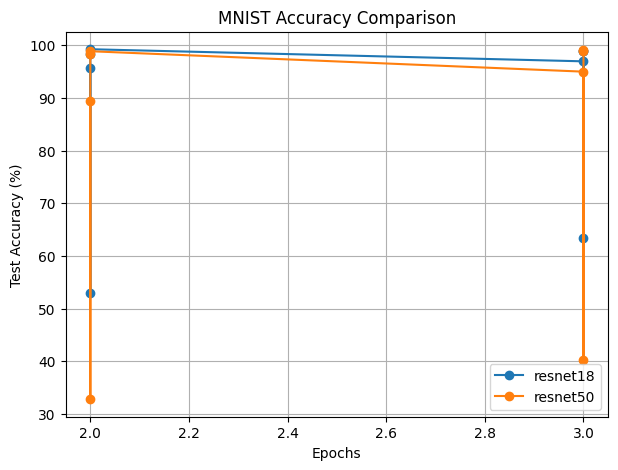

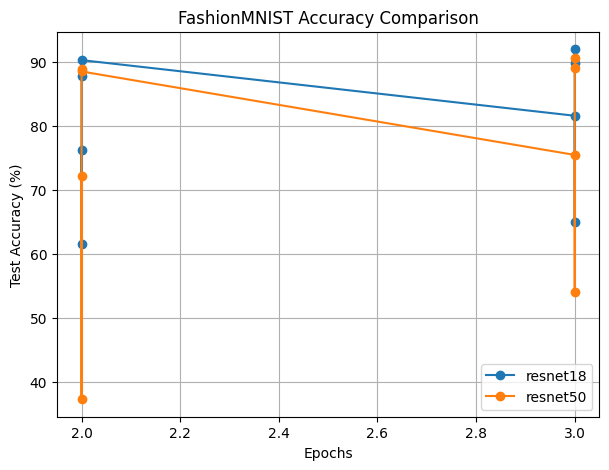

In [ ]:
for dataset in df["Dataset"].unique():
    subset = df[df["Dataset"] == dataset]

    plt.figure(figsize=(7,5))
    for model in subset["Model"].unique():
        model_data = subset[subset["Model"] == model]
        plt.plot(
            model_data["Epochs"],
            model_data["Test Accuracy (%)"],
            marker="o",
            label=model
        )

    plt.title(f"{dataset} Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Test Accuracy (%)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
for dataset in best_models:
    for model in best_models[dataset]:
        info = best_models[dataset][model]
        print(f"{dataset} | {model} → Best Acc: {info['acc']:.2f}% | Saved as {info['path']}")


MNIST | resnet18 → Best Acc: 99.27% | Saved as best_mnist_resnet18.pth
MNIST | resnet50 → Best Acc: 99.21% | Saved as best_mnist_resnet50.pth
FashionMNIST | resnet18 → Best Acc: 91.97% | Saved as best_fashion_resnet18.pth
FashionMNIST | resnet50 → Best Acc: 90.64% | Saved as best_fashion_resnet50.pth
